Assignment 2
Implement Simple and Multiple Linear Regression to predict continuous variables. a.
Perform data preprocessing (handle missing values, feature scaling). b. Fit a Simple
Linear Regression model on a dataset (e.g., predicting house prices). c. Extend to
Multiple Linear Regression with multiple features. d. Evaluate models using MSE,
RMSE, and R² Score. e. Visualize the regression line and predictions.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import os

In [ ]:
import kagglehub

In [ ]:
path = kagglehub.dataset_download("farhanmd29/50-startups")

print("Path to dataset files:", path)

100%|██████████| 1.30k/1.30k [00:00<00:00, 2.39MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/farhanmd29/50-startups/versions/1


In [ ]:
file_path = os.path.join(path, "50_Startups.csv")
data = pd.read_csv(file_path)

data.head()

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94


In [ ]:
X_simple = data[["R&D Spend"]]
data = data.fillna(data.mean(numeric_only=True))
data = pd.get_dummies(data, drop_first=True)
scaler = StandardScaler()
X = data.drop("Profit", axis=1)
y = data["Profit"]
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(
X_scaled, y, test_size=0.2, random_state=42
)
X_simple_scaled = scaler.fit_transform(X_simple)
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
X_simple_scaled, y, test_size=0.2, random_state=42
)

In [ ]:
model_simple = LinearRegression()
model_simple.fit(X_train_s, y_train_s)

LinearRegression()

In [ ]:
y_pred_simple = model_simple.predict(X_test_s)

In [ ]:
mse_s = mean_squared_error(y_test_s, y_pred_simple)
rmse_s = np.sqrt(mse_s)
r2_s = r2_score(y_test_s, y_pred_simple)
print("Simple Linear Regression:")
print("MSE:", mse_s)
print("RMSE:", rmse_s)
print("R2:", r2_s)

Simple Linear Regression:
MSE: 59510962.80787997
RMSE: 7714.334890830185
R2: 0.9265108109341951


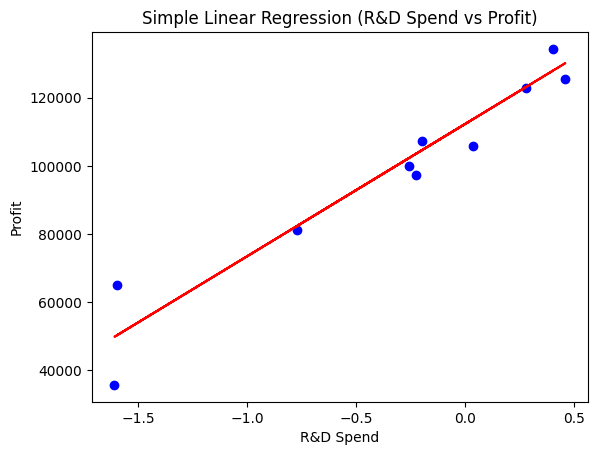

In [ ]:
plt.scatter(X_test_s, y_test_s, color="blue")
plt.plot(X_test_s, y_pred_simple, color="red")
plt.xlabel("R&D Spend")
plt.ylabel("Profit")
plt.title("Simple Linear Regression (R&D Spend vs Profit)")
plt.show()

In [ ]:
model_multi = LinearRegression()
model_multi.fit(X_train, y_train)
y_pred_multi = model_multi.predict(X_test)
mse_m = mean_squared_error(y_test, y_pred_multi)
rmse_m = np.sqrt(mse_m)
r2_m = r2_score(y_test, y_pred_multi)
print("\nMultiple Linear Regression:")
print("MSE:", mse_m)
print("RMSE:", rmse_m)
print("R2:", r2_m)


Multiple Linear Regression:
MSE: 82010363.04501365
RMSE: 9055.957323497812
R2: 0.8987266414319837


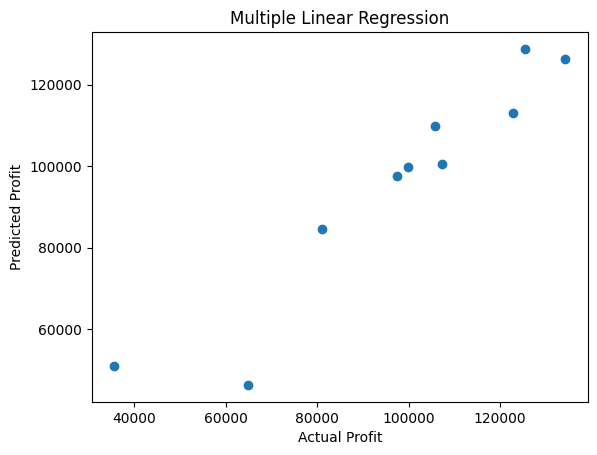

In [ ]:
plt.scatter(y_test, y_pred_multi)
plt.xlabel("Actual Profit")
plt.ylabel("Predicted Profit")
plt.title("Multiple Linear Regression")
plt.show()

Conclusion
The 50_Startups dataset was used to predict startup profit.
Data preprocessing included missing value handling, encoding categorical data, and
feature scaling.
4/5
https://colab.research.google.com/drive/1FoIqISxZxnE9h-YiSszsYAtxPI46QOdt#scrollTo=RbT8yss6U7qW&printMode=true
1/30/26, 4:55 PM
DL Assignment 2.ipynb - Colab
Simple Linear Regression analyzed the effect of R&D spend on profit.
Multiple Linear Regression used all relevant expenditures and state information.
Performance was evaluated using MSE, RMSE, and R² score.
Multiple Linear Regression achieved better accuracy due to multiple contributing
factors.